Citations: Andrew Lucas: Ising formulations of many NP Problems. arXiv:1302.5843. 
https://arxiv.org/abs/1302.5843

Ising machine: Exact Cover

Given a universe U = {0, ..., n-1} and subsets V_0, ..., V_{N-1} whose union is U,
is there a sub-collection R of these subsets such that:
- no two chosen cover sets contain the same element as another
- their union is U - all the elements in the universe

i.e. every element of U appears in exactly one selected subset.

This is NP-complete (Karp). Lucas §4.1, Eq. 28:

Decision version (H = 0 means a solution exists):
  H_A = A * sum_alpha (1 - sum_{i: alpha in V_i} x_i)^2

Optimization version (find the smallest exact cover):
  H = H_A + H_B,  where H_B = B * sum_i x_i
  with A > nB to ensure constraints are never violated.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from helpers.helpers import init_random_spins

In [12]:
# ---- Hamiltonian Penalty Term ----

def get_ha(universe_size, subsets, x, A):
    """Penalty: each element of U must be covered exactly once.
    For each element alpha, sum the x_i for all subsets containing alpha.
    Penalise if this sum != 1."""
    ha = 0
    for alpha in range(universe_size):
        cover_sum = 0
        for i, subset in enumerate(subsets):
            if alpha in subset:
                cover_sum += x[i]
        ha += (1 - cover_sum) ** 2
    return A * ha

def get_hb(x, B):
    """Penalise using more subsets (only used in NP hard variant)."""
    return B * np.sum(x)

def calc_energy(universe_size, subsets, x, A, B):
    return get_ha(universe_size, subsets, x, A) + get_hb(x, B)

In [13]:
# ---- Metropolis / Simulated Annealing ----

def metropolis(universe_size, subsets, x, A, B, T_start, steps):
    N = len(x)
    x = x.copy()
    energy = calc_energy(universe_size, subsets, x, A, B)
    best_x = x.copy()
    best_energy = energy

    for step in range(steps):
        j = np.random.randint(0, N)
        x[j] = 1 - x[j]
        new_energy = calc_energy(universe_size, subsets, x, A, B)
        delta_energy = new_energy - energy

        T = T_start / (1 + step * 0.001)
        if delta_energy < 0 or np.random.rand() < np.exp(-delta_energy / T):
            energy = new_energy
            if energy < best_energy:
                best_energy = energy
                best_x = x.copy()
        else:
            x[j] = 1 - x[j]

    return best_x, best_energy

In [14]:
# ---- Verification ----

def verify_exact_cover(universe_size, subsets, x):
    """Check that selected subsets form an exact cover."""
    selected = [i for i in range(len(x)) if x[i] == 1]
    coverage = [0] * universe_size

    for i in selected:
        for alpha in subsets[i]:
            coverage[alpha] += 1

    valid = True
    for alpha in range(universe_size):
        if coverage[alpha] == 0:
            print(f"  Element {alpha} is NOT covered")
            valid = False
        elif coverage[alpha] > 1:
            print(f"  Element {alpha} is covered {coverage[alpha]} times (should be 1)")
            valid = False

    if valid:
        print(f"VALID exact cover using {len(selected)} subsets: {selected}")
    else:
        print(f"INVALID exact cover")
    return valid

In [15]:
# ---- Plotting ----

def plot_exact_cover(universe_size, subsets, x):
    selected = [i for i in range(len(x)) if x[i] == 1]
    fig, ax = plt.subplots(figsize=(10, 4))

    colours = plt.cm.Set3(np.linspace(0, 1, len(subsets)))

    # draw each subset as a row
    for i, subset in enumerate(subsets):
        is_selected = x[i] == 1
        for alpha in subset:
            rect = plt.Rectangle((alpha, i), 0.9, 0.9,
                                 facecolor=colours[i] if is_selected else 'white',
                                 edgecolor='black' if is_selected else 'lightgray',
                                 linewidth=2 if is_selected else 1)
            ax.add_patch(rect)
            ax.text(alpha + 0.45, i + 0.45, str(alpha),
                    ha='center', va='center', fontsize=10,
                    color='black' if is_selected else 'lightgray')

    ax.set_xlim(-0.5, universe_size + 0.5)
    ax.set_ylim(-0.5, len(subsets) + 0.5)
    ax.set_xlabel('Universe elements')
    ax.set_ylabel('Subsets')
    ax.set_yticks([i + 0.45 for i in range(len(subsets))])
    labels = [f"V{i}{'*' if x[i]==1 else ''}" for i in range(len(subsets))]
    ax.set_yticklabels(labels)
    ax.set_xticks([i + 0.45 for i in range(universe_size)])
    ax.set_xticklabels(range(universe_size))
    ax.set_title(f"Exact Cover (selected subsets marked with *)")
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

In [16]:
# ---- Example 1: Small instance with known solution ----
# U = {0, 1, 2, 3, 4}
# V0 = {0, 1}, V1 = {2, 3}, V2 = {4}, V3 = {0, 2, 4}, V4 = {1, 3}
# Exact covers: {V0, V1, V2} or {V3, V4}

universe_size = 5
subsets = [
    {0, 1},     # V0
    {2, 3},     # V1
    {4},        # V2
    {0, 2, 4},  # V3
    {1, 3},     # V4
]

print(f"Universe: {{0, ..., {universe_size - 1}}}")
for i, s in enumerate(subsets):
    print(f"  V{i} = {s}")
print(f"Known exact covers: {{V0, V1, V2}} or {{V3, V4}}")

Universe: {0, ..., 4}
  V0 = {0, 1}
  V1 = {2, 3}
  V2 = {4}
  V3 = {0, 2, 4}
  V4 = {1, 3}
Known exact covers: {V0, V1, V2} or {V3, V4}



Selected subsets: ['V3', 'V4']
Energy: [0.] (H=0 means exact cover exists)
H_A: [0.]
VALID exact cover using 2 subsets: [3, 4]


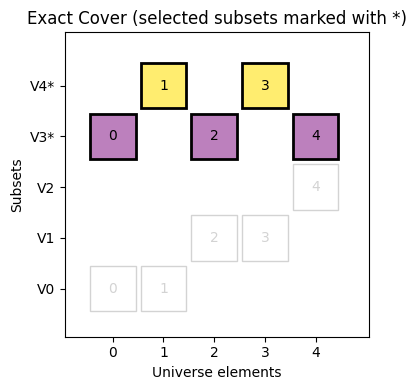

In [17]:
# ---- Solve (decision version: B=0, just find any exact cover) ----

N = len(subsets)
A = 1.0
B = 0.0  # pure decision: just find any exact cover
T_start = 5.0
steps = 100000

x = init_random_spins(N, num_dimensions=1)
best_x, best_energy = metropolis(universe_size, subsets, x, A, B, T_start, steps)

selected = [i for i in range(N) if best_x[i] == 1]
print(f"\nSelected subsets: {['V' + str(i) for i in selected]}")
print(f"Energy: {best_energy} (H=0 means exact cover exists)")
print(f"H_A: {get_ha(universe_size, subsets, best_x, A)}")
verify_exact_cover(universe_size, subsets, best_x)
plot_exact_cover(universe_size, subsets, best_x)

x [0 1 0 0 0]

Smallest exact cover found: ['V0', 'V1', 'V2']
Size: 3
Energy: 3.0
H_A (should be 0): 0.0
VALID exact cover using 3 subsets: [0, 1, 2]


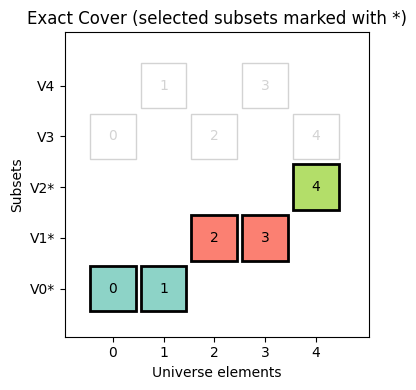

In [18]:
# ---- Solve (optimization version: find the smallest exact cover) ----

A = 10.0
B = 1.0   # A > n*B ensures constraints aren't violated
T_start = 5.0
steps = 200000

x = init_random_spins(N, num_dimensions=1).flatten()
print("x", x)
best_x, best_energy = metropolis(universe_size, subsets, x, A, B, T_start, steps)

selected = [i for i in range(N) if best_x[i] == 1]
print(f"\nSmallest exact cover found: {['V' + str(i) for i in selected]}")
print(f"Size: {len(selected)}")
print(f"Energy: {best_energy}")
print(f"H_A (should be 0): {get_ha(universe_size, subsets, best_x, A)}")
verify_exact_cover(universe_size, subsets, best_x)
plot_exact_cover(universe_size, subsets, best_x)

In [19]:
# ---- Example 2: Larger random instance ----

def generate_random_exact_cover_instance(universe_size, num_subsets, max_subset_size=3):
    """Generate a random instance guaranteed to have at least one exact cover."""
    # first, create a guaranteed exact cover by partitioning the universe
    elements = list(range(universe_size))
    np.random.shuffle(elements)
    guaranteed_subsets = []
    i = 0
    while i < universe_size:
        size = min(np.random.randint(1, max_subset_size + 1), universe_size - i)
        guaranteed_subsets.append(set(elements[i:i + size]))
        i += size

    # add random extra subsets to make it harder
    extra_subsets = []
    for _ in range(num_subsets - len(guaranteed_subsets)):
        size = np.random.randint(1, max_subset_size + 1)
        subset = set(np.random.choice(universe_size, size=size, replace=False))
        extra_subsets.append(subset)

    all_subsets = guaranteed_subsets + extra_subsets
    np.random.shuffle(all_subsets)
    return all_subsets

universe_size = 8
num_subsets = 12
subsets = generate_random_exact_cover_instance(universe_size, num_subsets)

print(f"Universe: {{0, ..., {universe_size - 1}}}")
for i, s in enumerate(subsets):
    print(f"  V{i} = {s}")

Universe: {0, ..., 7}
  V0 = {3, 5}
  V1 = {4}
  V2 = {np.int64(2), np.int64(6)}
  V3 = {np.int64(5)}
  V4 = {np.int64(3), np.int64(4), np.int64(6)}
  V5 = {0, 2, 7}
  V6 = {np.int64(2), np.int64(3), np.int64(6)}
  V7 = {6}
  V8 = {1}
  V9 = {np.int64(3), np.int64(6)}
  V10 = {np.int64(4)}
  V11 = {np.int64(1), np.int64(2)}



Exact cover found: ['V3', 'V4', 'V5', 'V8']
Size: 4
Energy: 4.0
H_A (should be 0): 0.0
VALID exact cover using 4 subsets: [3, 4, 5, 8]


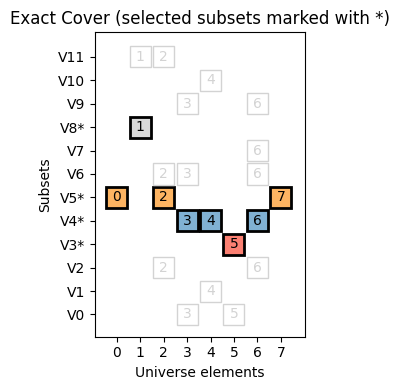

In [21]:
N = len(subsets)
A = 10.0
B = 1.0
T_start = 5.0
steps = 500000

x = init_random_spins(N, num_dimensions=1).flatten()
best_x, best_energy = metropolis(universe_size, subsets, x, A, B, T_start, steps)

selected = [i for i in range(N) if best_x[i] == 1]
print(f"\nExact cover found: {['V' + str(i) for i in selected]}")
print(f"Size: {len(selected)}")
print(f"Energy: {best_energy}")
print(f"H_A (should be 0): {get_ha(universe_size, subsets, best_x, A)}")
verify_exact_cover(universe_size, subsets, best_x)
plot_exact_cover(universe_size, subsets, best_x)